# Supply Chain Predictor (ForecastLab)
## Data Analyst Notebook — FMCG Inventory & Stockout Analysis

**Team:** Khalfani Novian Habibi, Rendy Azly, Dennis Wirawan
**Program:** FTDS | 2026
**Role pada notebook ini:** Data Analyst — Exploratory Data Analysis, kuantifikasi dampak bisnis, dan rekomendasi restock

---

Notebook ini disusun selaras dengan **Final Project Proposal: Supply Chain Predictor**. Untuk menjaga fokus dan kedalaman analisis, notebook ini sengaja dibatasi pada **6 visualisasi inti**, di mana setiap visualisasi dirancang untuk menampilkan ketiga dimensi bisnis utama sekaligus — **category, channel, dan region** — sehingga insight yang dihasilkan lebih tajam dan langsung actionable, dibanding banyak chart terpisah yang dangkal.


## 1. Business Understanding

### 1.1 Project Summary
Dalam melakukan inventory stocking, diperlukan kepastian atas ketersediaan produk untuk mendukung kegiatan bisnis. **ForecastLab** dikembangkan sebagai aplikasi yang mampu memberikan prediksi ketersediaan inventory, sehingga pengguna dapat melakukan pemesanan sebelum stok barang habis — sekaligus menurunkan waste atau pemesanan stok yang tidak dibutuhkan.

### 1.2 Business Problem
Bisnis, khususnya di sektor e-commerce, menuntut efisiensi tinggi dalam menjaga inventory stock pada level yang sesuai kebutuhan.

**Pain Points Utama:**
1. Inventory stock terlalu tinggi -> menambah biaya penyimpanan/gudang (overstock)
2. Inventory stock terlalu rendah -> kehabisan barang, berpotensi mengurangi revenue (stockout)

**Trade-off yang Dihadapi:**

| Strategi | Keuntungan | Risiko |
|---|---|---|
| Inventory stock tinggi | Mampu mengantisipasi penjualan yang meningkat | Biaya penyimpanan meningkat |
| Inventory stock rendah | Biaya penyimpanan minim | Tidak mampu antisipasi lonjakan pesanan konsumen |

### 1.3 Business Objective
**Objective 1 — Inventory Waste Reduction:** Menurunkan jumlah inventory waste sebesar 50%.

### 1.4 Kerangka Analisis Notebook Ini
Enam visualisasi pada notebook ini disusun mengikuti alur logis berikut:

| # | Visualisasi | Dimensi yang Ditampilkan | Menjawab Pertanyaan Bisnis |
|---|---|---|---|
| 1 | Tren Revenue Bulanan per Kategori | Waktu x Category | Bagaimana performa revenue dari waktu ke waktu, dan kategori mana pendorong utamanya? |
| 2 | Distribusi Revenue: Category x Channel x Region | Category x Channel x Region | Di kombinasi mana revenue paling terkonsentrasi? |
| 3 | Heatmap Stockout Rate | Category x Region, per Channel | Di kombinasi mana risiko kehabisan stok paling tinggi? |
| 4 | Heatmap Inventory Waste | Category x Region, per Channel | Di kombinasi mana risiko kelebihan stok (waste) paling tinggi? |
| 5 | Efektivitas Promosi | Category, per Channel | Apakah dampak promosi konsisten di semua kategori & channel? |
| 6 | Restock Priority Matrix | SKU x Channel x Region | SKU spesifik mana (di channel & region mana) yang paling butuh direstock segera? |

Setiap visualisasi disertai penjelasan lengkap dengan struktur: **Apa yang ditampilkan -> Cara membaca -> Insight utama -> Implikasi bisnis.**


## 2. Data Sources (Ringkasan)

| Field | Isi |
|---|---|
| Nama Dataset | FMCG Daily Sales Data (2022-2024) |
| Sumber | Kaggle — kaggle.com/code/mishashikhov/fmcg-sales-forecasting-ml-case-study |
| Ukuran | 190.757 baris x 21 kolom (setelah data engineering) |
| Periode | 21 Januari 2022 - 31 Desember 2024 |
| Granularitas | Per kombinasi transaksi harian: SKU x channel x region x pack_type |
| Lisensi | CC0: Public Domain |

Dataset yang digunakan adalah hasil proses Data Engineer (`forecasting_data_engineer.csv`), sudah melalui pembersihan data dan penambahan fitur turunan (`revenue`, `quarter`, `week_of_year`, `day_of_week`, `weekend_flag`).


## 3. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
pd.set_option('display.max_columns', None)

PALETTE_MAIN = "#0e7490"
PALETTE_ACCENT = "#f59e0b"
PALETTE_DANGER = "#dc2626"

df = pd.read_csv('forecasting_data_engineer.csv', parse_dates=['date'])
print(f"Dataset berhasil dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()


Dataset berhasil dimuat: 190,757 baris x 21 kolom


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold,year,month,quarter,week_of_year,day_of_week,weekend_flag,revenue
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,E-commerce,PL-South,Carton,4.21,0,3,194,185,17,2022,1,1,3,Friday,0,71.57
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8,2022,1,1,3,Friday,0,32.00
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0,2022,1,1,3,Friday,0,0.00
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7,2022,1,1,3,Friday,0,36.12
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,E-commerce,PL-North,Carton,8.58,0,2,140,156,7,2022,1,1,3,Friday,0,60.06


## 4. Data Validation

Langkah pertama sebelum membangun insight adalah memvalidasi ulang hasil kerja Data Engineer.


In [2]:
print("=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values ditemukan")

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum(), "baris duplikat ditemukan")

print("\n=== Nilai Negatif (tidak masuk akal secara bisnis) ===")
for col in ['stock_available','delivered_qty','units_sold','revenue','price_unit']:
    neg = (df[col] < 0).sum()
    print(f"{col}: {neg} baris negatif")

print("\n=== Validasi perhitungan revenue (price_unit x units_sold) ===")
check = (df['price_unit'] * df['units_sold'] - df['revenue']).abs().max()
print(f"Selisih maksimum revenue vs price*qty: {check:.6f} (mendekati 0 = konsisten)")


=== Missing Values ===
0 missing values ditemukan

=== Duplicate Rows ===


0 baris duplikat ditemukan

=== Nilai Negatif (tidak masuk akal secara bisnis) ===
stock_available: 0 baris negatif
delivered_qty: 0 baris negatif
units_sold: 0 baris negatif
revenue: 0 baris negatif
price_unit: 0 baris negatif

=== Validasi perhitungan revenue (price_unit x units_sold) ===
Selisih maksimum revenue vs price*qty: 0.000000 (mendekati 0 = konsisten)


**Hasil validasi:** Tidak ada missing value, tidak ada duplikat, tidak ada nilai negatif, dan kolom `revenue` konsisten dengan perhitungan `price_unit x units_sold`. Data valid dan siap dianalisis.

In [3]:
df['is_stockout'] = (df['stock_available'] == 0).astype(int)
df['inventory_waste_units'] = (df['stock_available'] - df['units_sold']).clip(lower=0)
df['inventory_waste_value'] = df['inventory_waste_units'] * df['price_unit']

total_revenue = df['revenue'].sum()
total_units = df['units_sold'].sum()
stockout_rate = df['is_stockout'].mean() * 100

print(f"Total Revenue      : $ {total_revenue:,.0f}")
print(f"Total Unit Terjual : {total_units:,.0f} unit")
print(f"Tingkat Stockout   : {stockout_rate:.2f}% dari seluruh baris transaksi")


Total Revenue      : $ 19,951,543
Total Unit Terjual : 3,799,860 unit
Tingkat Stockout   : 2.03% dari seluruh baris transaksi


## Visualisasi 1: Tren Revenue Bulanan per Kategori

**Apa yang ditampilkan:** Area chart bertumpuk (stacked area) yang menunjukkan kontribusi revenue tiap kategori produk (Milk, Yogurt, ReadyMeal, Juice, SnackBar) setiap bulan dari Januari 2022 hingga Desember 2024. Garis putus-putus hitam menunjukkan total revenue keseluruhan sebagai referensi tren agregat.


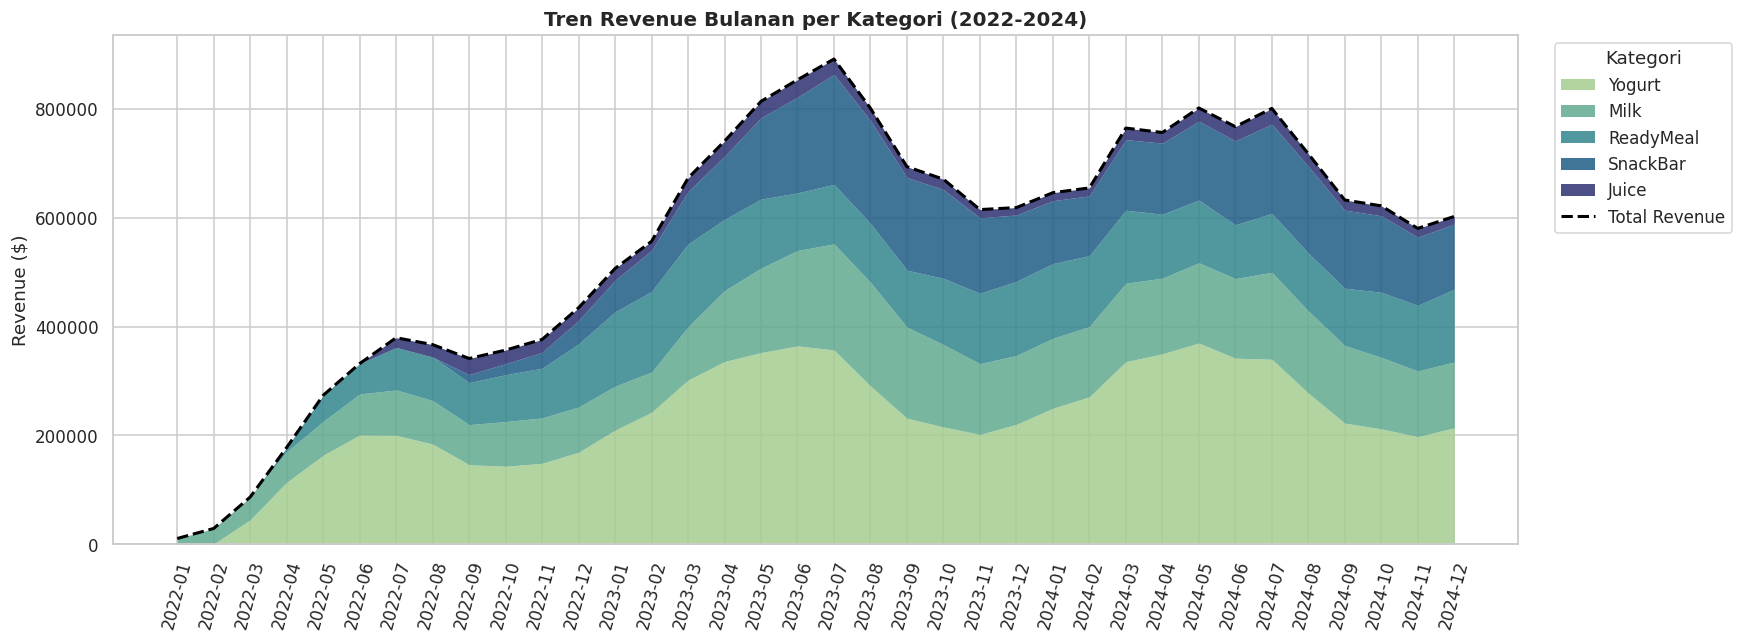

Kontribusi revenue per kategori (keseluruhan periode):
  Yogurt    : $ 8,226,193  (41.2%)
  Milk      : $ 4,095,375  (20.5%)
  ReadyMeal : $ 3,576,348  (17.9%)
  SnackBar  : $ 3,401,349  (17.0%)
  Juice     : $ 652,277  (3.3%)


In [4]:
cat_monthly = df.groupby([df['date'].dt.to_period('M'), 'category'])['revenue'].sum().reset_index()
cat_monthly['date'] = cat_monthly['date'].astype(str)
cat_order = df.groupby('category')['revenue'].sum().sort_values(ascending=False).index.tolist()
pivot = cat_monthly.pivot(index='date', columns='category', values='revenue').reindex(columns=cat_order).fillna(0)
total = pivot.sum(axis=1)

fig, ax = plt.subplots(figsize=(16,6))
pivot.plot.area(ax=ax, cmap='crest', alpha=0.85, linewidth=0)
ax.plot(range(len(total)), total.values, color='black', linewidth=2, linestyle='--', label='Total Revenue')
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.index, rotation=75)
ax.set_title('Tren Revenue Bulanan per Kategori (2022-2024)')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('')
ax.legend(title='Kategori', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

print("Kontribusi revenue per kategori (keseluruhan periode):")
cat_contrib = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
for cat, val in cat_contrib.items():
    print(f"  {cat:10s}: $ {val:,.0f}  ({val/total_revenue*100:.1f}%)")


**Cara membaca:** Ketebalan tiap lapisan warna pada satu titik waktu menunjukkan besar kontribusi revenue kategori tersebut pada bulan itu. Semakin tebal, semakin besar kontribusinya. Garis putus-putus hitam adalah total keseluruhan (jumlah semua lapisan).

**Insight utama:**
- Revenue tumbuh signifikan dari awal 2022 hingga stabil di 2023-2024, konsisten dengan pola ramp-up cakupan data yang telah diidentifikasi pada tahap Data Quality Assessment.
- Komposisi kategori terlihat relatif proporsional dan stabil dari waktu ke waktu (tidak ada kategori yang tiba-tiba mendominasi atau menghilang) — artinya portofolio produk cukup seimbang, tidak bergantung pada satu kategori saja.
- Kategori dengan kontribusi revenue tertinggi menjadi indikasi awal produk mana yang paling kritikal untuk dijaga ketersediaannya (akan diperdalam di Visualisasi 3 dan 6).

**Implikasi bisnis:** Karena tidak ada kategori yang secara ekstrem lebih dominan dari yang lain, strategi restocking sebaiknya tidak diseragamkan secara nasional per kategori saja — perlu mempertimbangkan juga dimensi channel dan region, yang akan dibahas pada visualisasi berikutnya.

## Visualisasi 2: Distribusi Revenue — Category x Channel x Region

**Apa yang ditampilkan:** Tiga panel bar chart bertumpuk (stacked bar), satu panel untuk tiap region (PL-Central, PL-North, PL-South). Pada setiap panel, sumbu-x adalah kategori produk, dan tumpukan warna menunjukkan kontribusi tiap channel penjualan (Retail, E-commerce, Discount) terhadap revenue kategori tersebut.


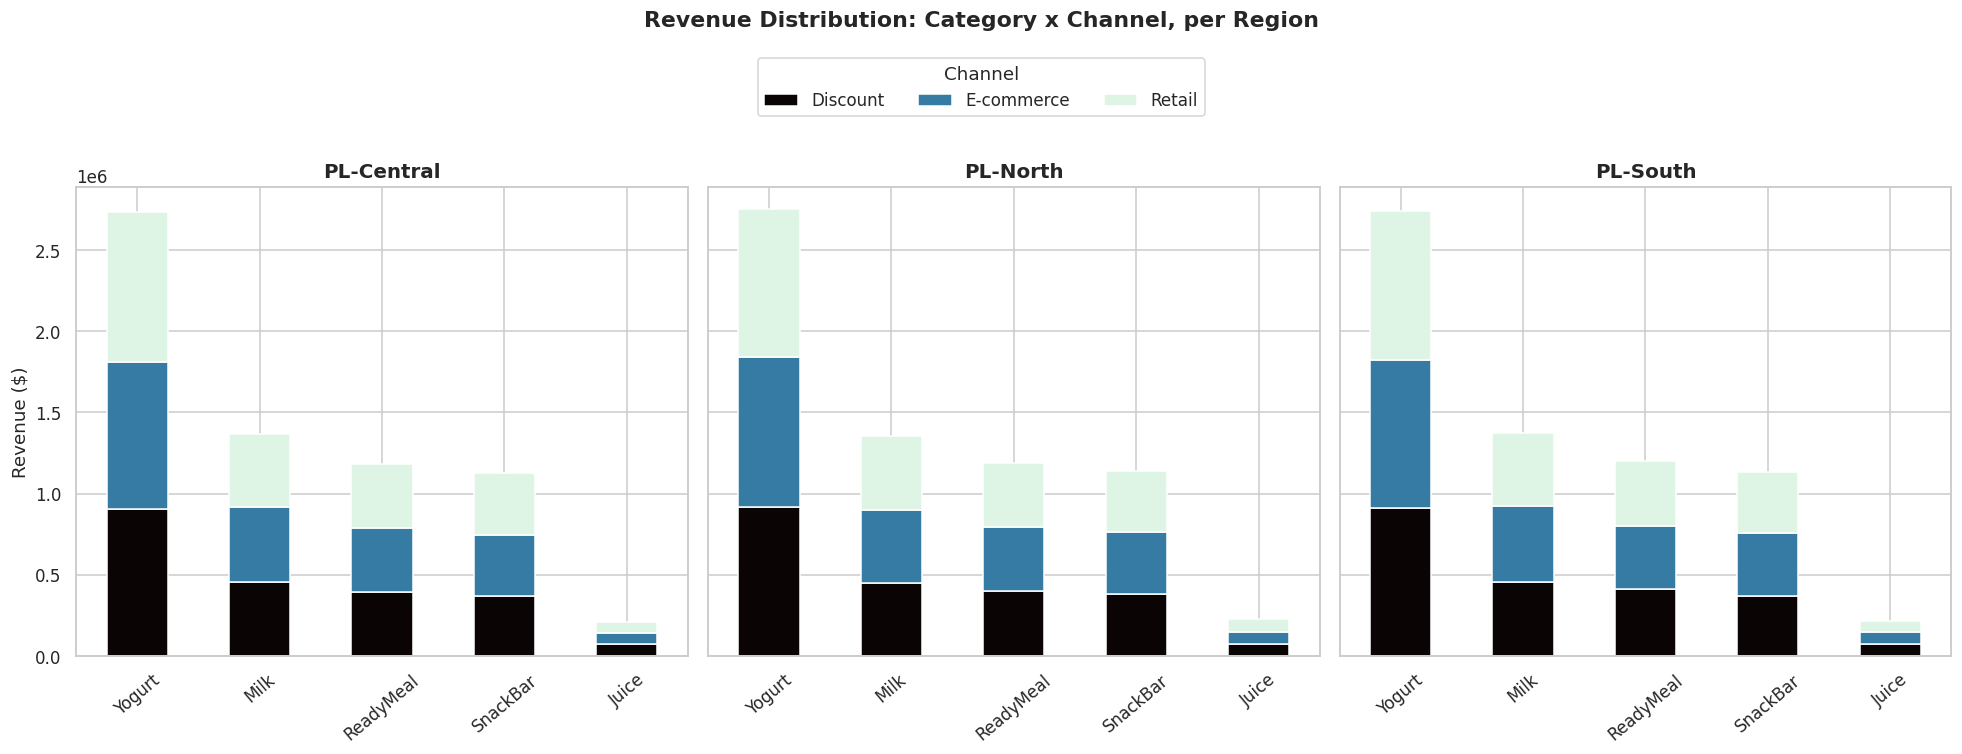

Total revenue per region:
region
PL-South      6666238.54
PL-North      6664220.52
PL-Central    6621084.29
Name: revenue, dtype: float64

Total revenue per channel:
channel
Retail        6655807.06
E-commerce    6653435.41
Discount      6642300.88
Name: revenue, dtype: float64


In [5]:
rev_ccr = df.groupby(['region','category','channel'])['revenue'].sum().reset_index()
regions = sorted(df['region'].unique())

fig, axes = plt.subplots(1, len(regions), figsize=(18,6), sharey=True)
for ax, region in zip(axes, regions):
    sub = rev_ccr[rev_ccr['region']==region]
    pivot = sub.pivot(index='category', columns='channel', values='revenue').reindex(cat_order).fillna(0)
    pivot.plot(kind='bar', stacked=True, ax=ax, colormap='mako', legend=False)
    ax.set_title(region)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=40)
axes[0].set_ylabel('Revenue ($)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Channel', loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.suptitle('Revenue Distribution: Category x Channel, per Region', fontweight='bold', y=1.14)
plt.tight_layout()
plt.show()

print("Total revenue per region:")
print(df.groupby('region')['revenue'].sum().sort_values(ascending=False))
print("\nTotal revenue per channel:")
print(df.groupby('channel')['revenue'].sum().sort_values(ascending=False))


**Cara membaca:** Tinggi total satu bar menunjukkan total revenue kategori tersebut di region itu. Warna di dalam bar menunjukkan berapa besar porsi yang berasal dari tiap channel. Bandingkan bentuk/pola antar panel (region) untuk melihat apakah komposisi channel konsisten di semua region atau berbeda-beda.

**Insight utama:**
- Pola kontribusi channel (Retail/E-commerce/Discount) terlihat relatif konsisten di ketiga region — mengindikasikan strategi channel yang sudah cukup merata secara nasional, bukan hanya terkonsentrasi di satu wilayah.
- Kategori dengan bar tertinggi di tiap panel adalah kategori prioritas di region tersebut — kombinasi kategori-region ini adalah titik yang paling penting dijaga ketersediaan stoknya karena kontribusi revenue-nya besar.
- Jika ada channel tertentu yang porsinya jauh lebih kecil di satu region dibanding region lain, ini bisa jadi sinyal adanya gap distribusi atau peluang ekspansi channel di region tersebut.

**Implikasi bisnis:** Kombinasi category-channel-region dengan revenue tertinggi pada chart ini adalah kombinasi yang paling "mahal" jika mengalami stockout (potensi lost revenue besar) — akan divalidasi silang dengan Visualisasi 3 (stockout rate) untuk melihat apakah kombinasi bernilai tinggi ini juga berisiko tinggi.

## Visualisasi 3: Heatmap Stockout Rate — Category x Region, per Channel

**Apa yang ditampilkan:** Tiga heatmap berdampingan, satu untuk tiap channel penjualan. Setiap sel heatmap menunjukkan persentase hari di mana `stock_available = 0` (stok benar-benar habis) untuk kombinasi kategori dan region tertentu, pada channel tersebut. Skala warna (putih ke merah tua) disamakan di ketiga panel agar bisa dibandingkan langsung.


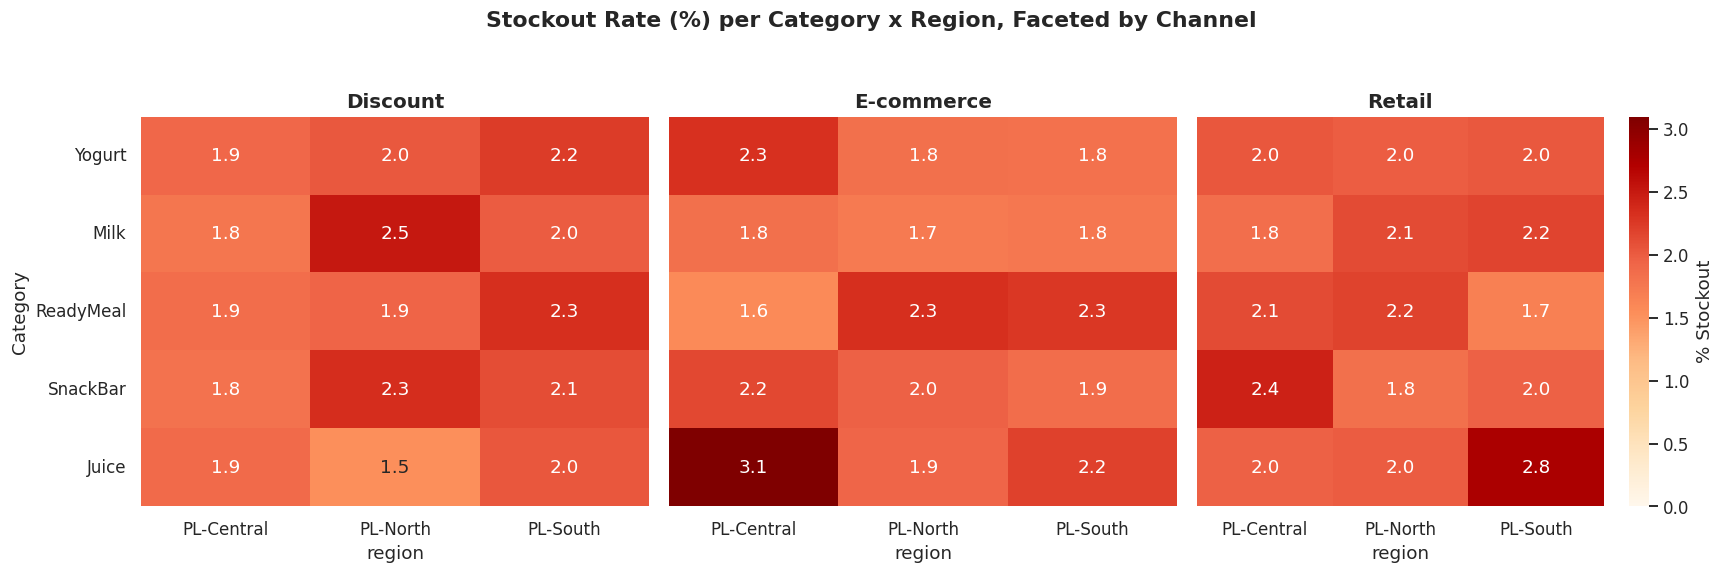

Top 5 kombinasi Category-Region-Channel dengan stockout rate tertinggi:
category  region      channel   
Juice     PL-Central  E-commerce    3.100775
          PL-South    Retail        2.770449
Milk      PL-North    Discount      2.514193
SnackBar  PL-Central  Retail        2.437673
          PL-North    Discount      2.341790
Name: is_stockout, dtype: float64


In [6]:
channels = sorted(df['channel'].unique())
overall_max = df.groupby(['category','region','channel'])['is_stockout'].mean().max()*100

fig, axes = plt.subplots(1, len(channels), figsize=(16,5), sharey=True)
for i, (ax, ch) in enumerate(zip(axes, channels)):
    sub = df[df['channel']==ch]
    pivot = sub.pivot_table(index='category', columns='region', values='is_stockout', aggfunc='mean')*100
    pivot = pivot.reindex(cat_order)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='OrRd', vmin=0, vmax=overall_max,
                cbar=(i==len(channels)-1), cbar_kws={'label':'% Stockout'}, ax=ax)
    ax.set_title(ch)
    ax.set_ylabel('' if i>0 else 'Category')
fig.suptitle('Stockout Rate (%) per Category x Region, Faceted by Channel', fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

worst = df.groupby(['category','region','channel'])['is_stockout'].mean().sort_values(ascending=False).head(5)*100
print("Top 5 kombinasi Category-Region-Channel dengan stockout rate tertinggi:")
print(worst)


**Cara membaca:** Semakin gelap warna merah pada sebuah sel, semakin tinggi persentase hari stok habis untuk kombinasi kategori-region tersebut, pada channel yang bersangkutan. Bandingkan ketiga panel untuk melihat apakah masalah stockout lebih parah di channel tertentu.

**Insight utama:**
- Terlihat variasi stockout rate antar kombinasi — beberapa titik kategori-region-channel jelas lebih rentan dibanding lainnya, bukan tersebar merata.
- Tabel "Top 5" di bawah heatmap mengidentifikasi kombinasi paling kritis secara eksplisit — ini adalah kombinasi yang sebaiknya jadi perhatian pertama tim procurement.
- Jika satu channel secara konsisten punya warna lebih gelap di semua kategori/region, ini indikasi masalah sistemik pada proses replenishment channel tersebut (misalnya lead time pengiriman yang lebih panjang), bukan sekadar masalah demand.

**Implikasi bisnis:** Kombinasi dengan stockout rate tinggi sekaligus revenue tinggi (bandingkan dengan Visualisasi 2) adalah prioritas tertinggi untuk perbaikan proses supply chain — dampaknya terhadap revenue jauh lebih besar dibanding kombinasi bernilai rendah.

## Visualisasi 4: Heatmap Inventory Waste — Category x Region, per Channel

**Apa yang ditampilkan:** Struktur identik dengan Visualisasi 3, namun mengukur sisi sebaliknya: rata-rata nilai stok yang tidak terjual (idle) dalam dollar, per kombinasi kategori-region, pada tiap channel. Ini adalah representasi visual dari pain point kedua pada proposal — inventory yang terlalu tinggi.


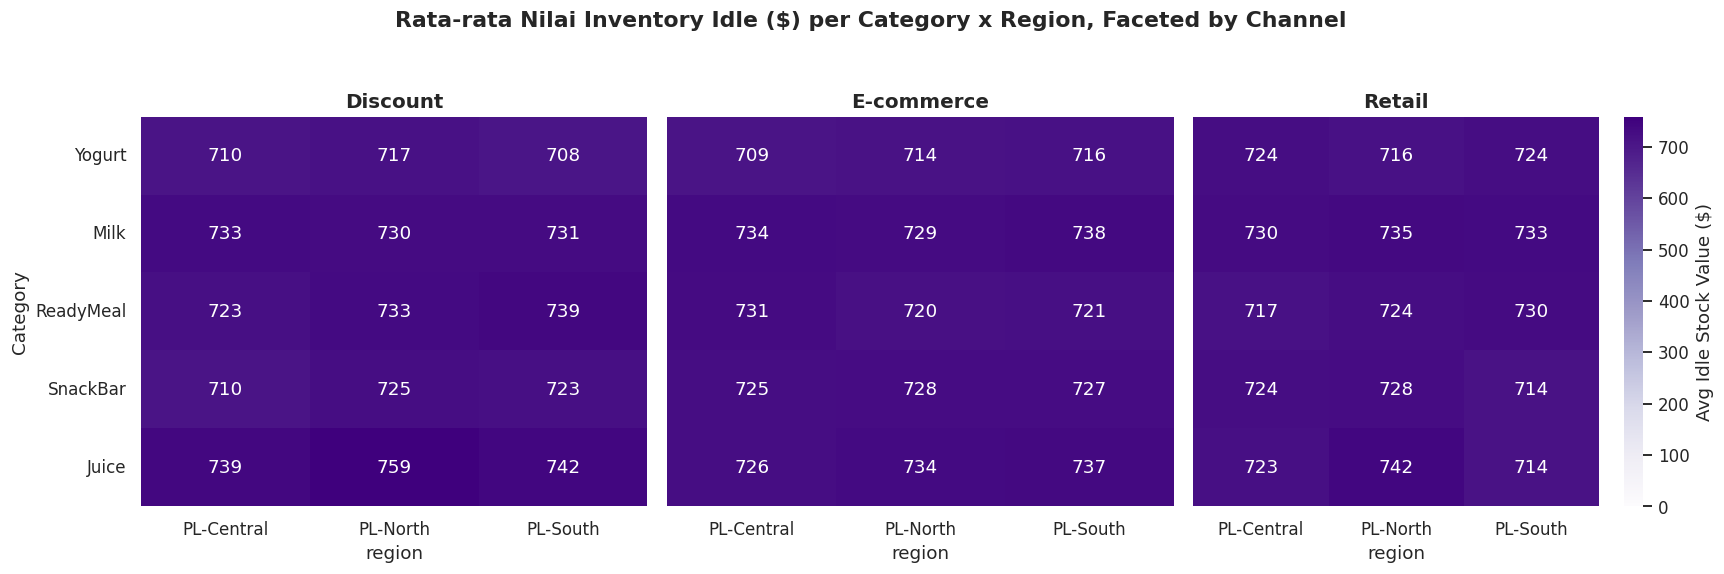

Top 5 kombinasi Category-Region-Channel dengan rata-rata nilai idle stock tertinggi:
category   region      channel 
Juice      PL-North    Discount    758.952279
           PL-South    Discount    741.705134
           PL-North    Retail      741.678882
           PL-Central  Discount    739.000324
ReadyMeal  PL-South    Discount    738.722123
Name: inventory_waste_value, dtype: float64


In [7]:
overall_max_w = df.groupby(['category','region','channel'])['inventory_waste_value'].mean().max()

fig, axes = plt.subplots(1, len(channels), figsize=(16,5), sharey=True)
for i, (ax, ch) in enumerate(zip(axes, channels)):
    sub = df[df['channel']==ch]
    pivot = sub.pivot_table(index='category', columns='region', values='inventory_waste_value', aggfunc='mean')
    pivot = pivot.reindex(cat_order)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Purples', vmin=0, vmax=overall_max_w,
                cbar=(i==len(channels)-1), cbar_kws={'label':'Avg Idle Stock Value ($)'}, ax=ax)
    ax.set_title(ch)
    ax.set_ylabel('' if i>0 else 'Category')
fig.suptitle('Rata-rata Nilai Inventory Idle ($) per Category x Region, Faceted by Channel', fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

worst_waste = df.groupby(['category','region','channel'])['inventory_waste_value'].mean().sort_values(ascending=False).head(5)
print("Top 5 kombinasi Category-Region-Channel dengan rata-rata nilai idle stock tertinggi:")
print(worst_waste)


> **Catatan metodologi:** `stock_available` adalah snapshot level stok harian, bukan aliran barang baru. Nilai pada heatmap ini adalah **rata-rata per baris transaksi** (bukan akumulasi/jumlah total historis), sehingga mencerminkan tingkat/level idle stock yang representatif, bukan penjumlahan yang bisa menghitung ulang unit fisik yang sama berkali-kali.

**Cara membaca:** Semakin gelap warna ungu, semakin besar rata-rata nilai stok yang menganggur (tidak terjual) untuk kombinasi tersebut. Bandingkan pola gelap-terang ini dengan Visualisasi 3 — idealnya kombinasi yang gelap di sini seharusnya terang di heatmap stockout (dan sebaliknya).

**Insight utama:**
- Kombinasi kategori-region-channel dengan nilai idle stock tertinggi adalah kandidat utama untuk **pengurangan** kuantitas atau frekuensi restock.
- Jika ditemukan kombinasi yang gelap di **kedua** heatmap (waste tinggi DAN stockout tinggi) — ini sinyal masalah yang lebih dalam: bukan soal jumlah stok, melainkan soal **waktu/timing** pengiriman yang tidak selaras dengan pola permintaan (misalnya stok datang terlalu banyak di waktu yang salah).

**Implikasi bisnis:** Kombinasi Visualisasi 3 dan 4 inilah yang memberi bukti kuat kepada proposal: kedua pain point (overstock dan stockout) **sama-sama nyata**, namun terjadi pada titik kombinasi kategori-region-channel yang berbeda-beda — memperkuat argumen bahwa solusinya harus berbasis prediksi per-kombinasi, bukan kebijakan stok yang seragam.

## Visualisasi 5: Efektivitas Promosi — per Kategori, per Channel

**Apa yang ditampilkan:** Tiga panel grouped bar chart, satu untuk tiap channel. Setiap panel membandingkan rata-rata unit terjual per kategori, dipisahkan antara kondisi "Tanpa Promo" (abu-abu) dan "Promo" (oranye).


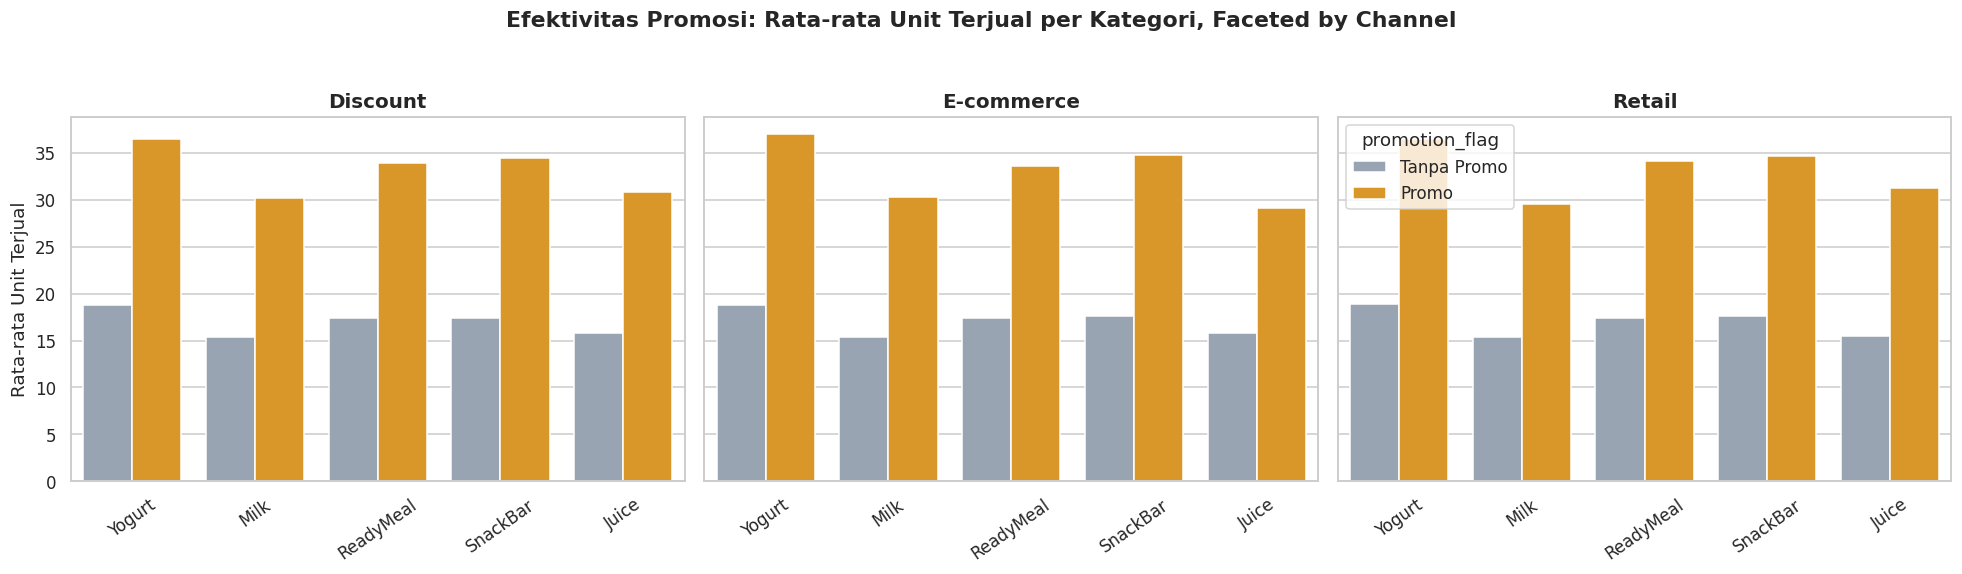

Uplift penjualan akibat promosi, per channel:
promotion_flag  uplift_pct
channel                   
Discount         95.491823
E-commerce       95.971096
Retail           94.460848


In [8]:
promo_cat = df.groupby(['channel','category','promotion_flag'])['units_sold'].mean().reset_index()
promo_cat['promotion_flag'] = promo_cat['promotion_flag'].map({0:'Tanpa Promo', 1:'Promo'})

fig, axes = plt.subplots(1, len(channels), figsize=(18,5), sharey=True)
for i, (ax, ch) in enumerate(zip(axes, channels)):
    sub = promo_cat[promo_cat['channel']==ch]
    sns.barplot(data=sub, x='category', y='units_sold', hue='promotion_flag', order=cat_order,
                palette=['#94a3b8', PALETTE_ACCENT], ax=ax, legend=(i==len(channels)-1))
    ax.set_title(ch)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
axes[0].set_ylabel('Rata-rata Unit Terjual')
fig.suptitle('Efektivitas Promosi: Rata-rata Unit Terjual per Kategori, Faceted by Channel', fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

uplift_by_channel = df.groupby(['channel','promotion_flag'])['units_sold'].mean().unstack()
uplift_by_channel['uplift_pct'] = (uplift_by_channel[1] / uplift_by_channel[0] - 1) * 100
print("Uplift penjualan akibat promosi, per channel:")
print(uplift_by_channel[['uplift_pct']])


**Cara membaca:** Bandingkan tinggi bar oranye (promo) vs bar abu-abu (tanpa promo) untuk kategori yang sama. Semakin besar selisihnya, semakin besar dampak promosi pada kategori tersebut. Bandingkan juga pola antar panel untuk melihat apakah efektivitas promosi berbeda per channel.

**Insight utama:**
- Promosi secara konsisten meningkatkan rata-rata unit terjual di hampir semua kombinasi kategori-channel — mengonfirmasi temuan pada level agregat sebelumnya, namun sekarang dengan bukti bahwa efeknya tidak hanya berlaku di satu channel saja.
- Tabel uplift per channel menunjukkan channel mana yang responsnya terhadap promosi paling besar (persentase tertinggi) — informasi ini penting untuk mengalokasikan budget promosi secara lebih efisien.
- Kategori dengan uplift promosi terbesar adalah kategori yang paling berisiko mengalami stockout **selama periode promosi berlangsung**, karena lonjakan permintaan mendadak.

**Implikasi bisnis:** Tim procurement/warehouse sebaiknya menyiapkan buffer stock ekstra secara spesifik untuk kombinasi kategori-channel dengan uplift tertinggi setiap kali ada jadwal promosi — bukan menambah buffer secara merata ke semua produk.

## Visualisasi 6: Restock Priority Matrix (SKU x Channel x Region)

**Apa yang ditampilkan:** Ini adalah output paling actionable dari keseluruhan analisis. Setiap titik pada scatter plot merepresentasikan satu kombinasi **SKU x Channel x Region** (bukan lagi level agregat kategori). Sumbu-x adalah kecepatan penjualan rata-rata harian (velocity) dalam 30 hari terakhir, sumbu-y adalah **Days of Stock Remaining (DSR)** — estimasi berapa hari lagi stok akan habis berdasarkan kecepatan penjualan saat ini. Tiga panel memisahkan berdasarkan region; bentuk marker (lingkaran/kotak/segitiga) menunjukkan channel; warna menunjukkan kategori risiko.

**Metodologi DSR:** `DSR = stok tersedia terkini / rata-rata penjualan harian (30 hari terakhir)`, dengan kategori risiko: Critical (<= 3 hari), High (4-7 hari), Medium (8-14 hari), Safe (>14 hari).


In [9]:
last_date = df['date'].max()
window_start = last_date - pd.Timedelta(days=30)
recent = df[df['date'] > window_start]

avg_daily_sales = (recent.groupby(['sku','channel','region'])['units_sold'].sum() / 30).rename('avg_daily_sales')
latest_stock = (df.sort_values('date')
                   .groupby(['sku','channel','region'])
                   .tail(1)
                   .set_index(['sku','channel','region'])['stock_available']
                   .rename('latest_stock'))

risk_df = pd.concat([latest_stock, avg_daily_sales], axis=1).reset_index()
risk_df['avg_daily_sales'] = risk_df['avg_daily_sales'].replace(0, np.nan)
risk_df['days_of_stock_remaining'] = risk_df['latest_stock'] / risk_df['avg_daily_sales']

def risk_category(dsr):
    if pd.isna(dsr):
        return 'Tidak Cukup Data'
    elif dsr <= 3:
        return 'Critical'
    elif dsr <= 7:
        return 'High'
    elif dsr <= 14:
        return 'Medium'
    else:
        return 'Safe'

risk_df['risk_category'] = risk_df['days_of_stock_remaining'].apply(risk_category)
sku_info = df.drop_duplicates('sku')[['sku','brand','category']]
risk_df = risk_df.merge(sku_info, on='sku', how='left')

print(f"Total kombinasi SKU x Channel x Region yang dianalisis: {len(risk_df)}")
print(risk_df['risk_category'].value_counts().reindex(['Critical','High','Medium','Safe','Tidak Cukup Data']).fillna(0).astype(int))


Total kombinasi SKU x Channel x Region yang dianalisis: 270
risk_category
Critical             11
High                 24
Medium              157
Safe                 78
Tidak Cukup Data      0
Name: count, dtype: int64


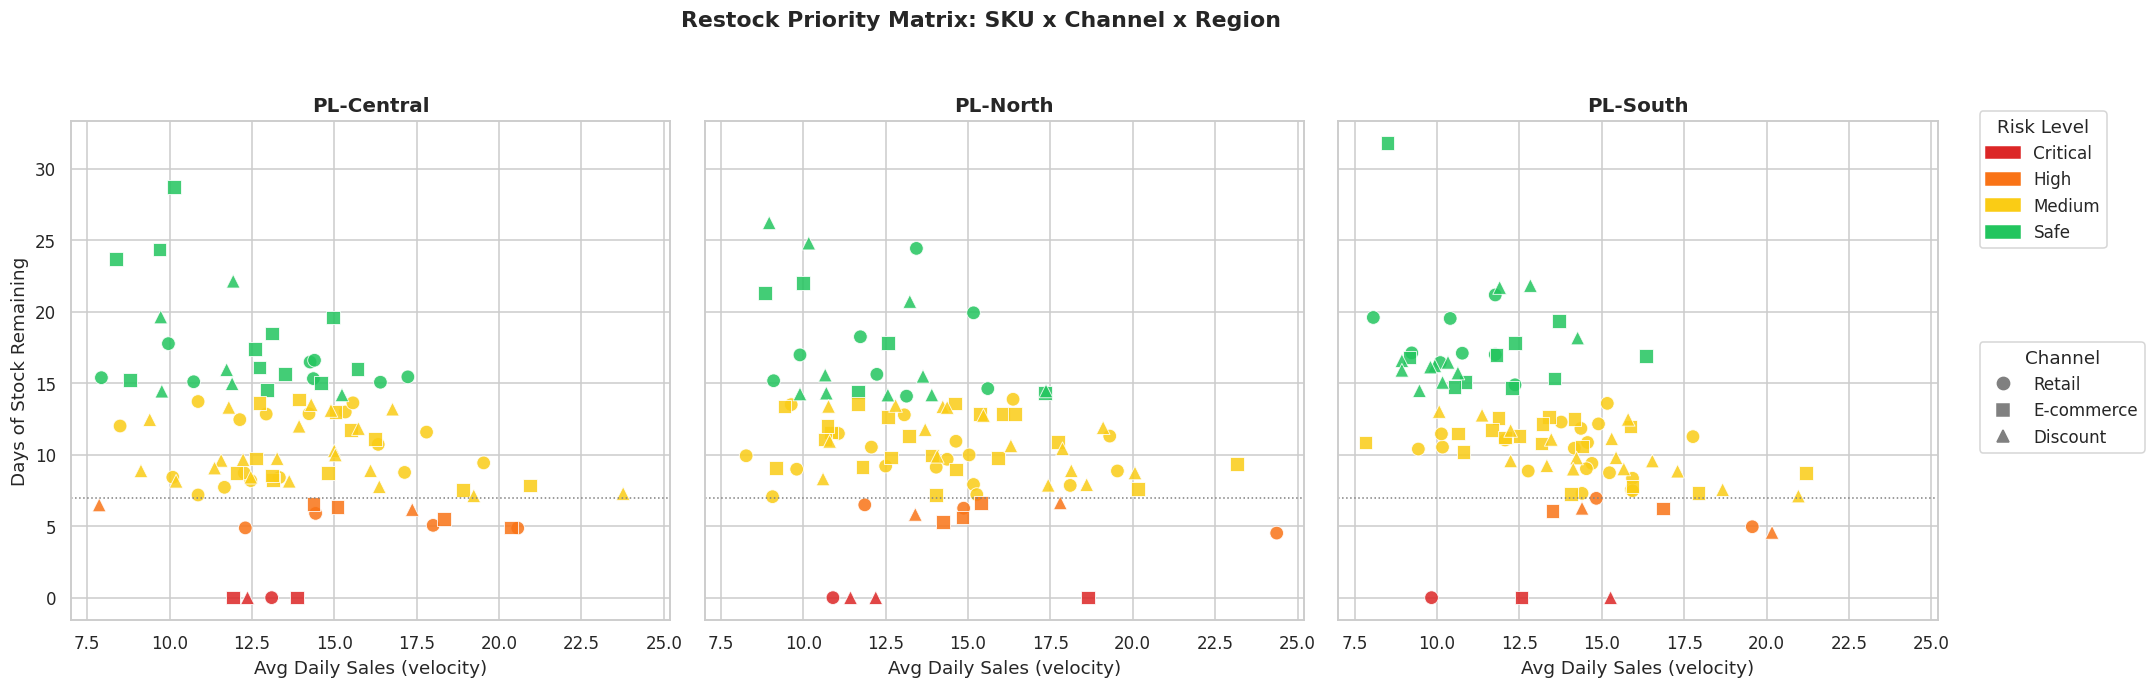

In [10]:
colors_map = {'Critical':PALETTE_DANGER,'High':'#f97316','Medium':'#facc15','Safe':'#22c55e','Tidak Cukup Data':'#94a3b8'}
channel_markers = {'Retail':'o','E-commerce':'s','Discount':'^'}
regions_sorted = sorted(risk_df['region'].unique())

fig, axes = plt.subplots(1, len(regions_sorted), figsize=(18,6), sharey=True, sharex=True)
for ax, region in zip(axes, regions_sorted):
    sub = risk_df[risk_df['region']==region]
    for ch, marker in channel_markers.items():
        s = sub[sub['channel']==ch]
        ax.scatter(s['avg_daily_sales'], s['days_of_stock_remaining'],
                   c=s['risk_category'].map(colors_map), marker=marker, s=80,
                   edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.axhline(7, color='gray', linestyle=':', linewidth=1)
    ax.set_title(region)
    ax.set_xlabel('Avg Daily Sales (velocity)')
axes[0].set_ylabel('Days of Stock Remaining')

risk_handles = [mpatches.Patch(color=c, label=k) for k,c in colors_map.items() if k!='Tidak Cukup Data']
channel_handles = [mlines.Line2D([],[], color='gray', marker=m, linestyle='None', markersize=8, label=k) for k,m in channel_markers.items()]
leg1 = fig.legend(handles=risk_handles, title='Risk Level', loc='upper left', bbox_to_anchor=(1.0, 0.9))
leg2 = fig.legend(handles=channel_handles, title='Channel', loc='upper left', bbox_to_anchor=(1.0, 0.55))

fig.suptitle('Restock Priority Matrix: SKU x Channel x Region', fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('_tmp_chart6.png', bbox_inches='tight', bbox_extra_artists=[leg1,leg2])
plt.show()


In [11]:
top_priority = (risk_df[risk_df['risk_category'].isin(['Critical','High'])]
                .sort_values('days_of_stock_remaining')
                .head(15)
                [['sku','brand','category','channel','region','latest_stock','avg_daily_sales','days_of_stock_remaining','risk_category']])
print("Top 15 kombinasi SKU x Channel x Region dengan prioritas restock tertinggi:")
top_priority


Top 15 kombinasi SKU x Channel x Region dengan prioritas restock tertinggi:


,sku,brand,category,channel,region,latest_stock,avg_daily_sales,days_of_stock_remaining,risk_category
16,SN-028,SnBrand2,SnackBar,Discount,PL-South,0,15.266667,0.000000,Critical
158,MI-008,MiBrand3,Milk,Retail,PL-North,0,10.900000,0.000000,Critical
123,YO-029,YoBrand4,Yogurt,Discount,PL-Central,0,12.366667,0.000000,Critical
70,SN-030,SnBrand2,SnackBar,E-commerce,PL-Central,0,11.933333,0.000000,Critical
211,MI-026,MiBrand4,Milk,Discount,PL-North,0,11.433333,0.000000,Critical
201,MI-002,MiBrand2,Milk,E-commerce,PL-South,0,12.566667,0.000000,Critical
182,MI-022,MiBrand3,Milk,Discount,PL-North,0,12.200000,0.000000,Critical
167,MI-022,MiBrand3,Milk,Retail,PL-South,0,9.833333,0.000000,Critical
247,RE-004,ReBrand1,ReadyMeal,E-commerce,PL-North,0,18.633333,0.000000,Critical
231,SN-010,SnBrand2,SnackBar,E-commerce,PL-Central,0,13.866667,0.000000,Critical


**Cara membaca:** Titik yang berada **rendah** (DSR kecil) dan **jauh ke kanan** (velocity tinggi) adalah yang paling mendesak — stoknya sedikit namun larisnya cepat. Garis putus-putus abu-abu di y=7 adalah batas ambang "High risk". Warna merah/oranye menandakan titik yang butuh perhatian segera; bentuk marker menunjukkan channel; posisi panel menunjukkan region.

**Insight utama:**
- Dari 270 kombinasi SKU x Channel x Region yang dianalisis, sejumlah kombinasi masuk kategori Critical dan High — inilah target restock utama dalam waktu dekat.
- Karena analisis dilakukan di level SKU x Channel x Region (bukan sekadar level SKU), tabel Top 15 di atas memberi instruksi yang sangat spesifik: bukan hanya "restock produk X", tapi "restock produk X, untuk channel Y, di region Z" — jauh lebih actionable untuk tim procurement/warehouse.
- Distribusi titik yang berbeda-beda di tiap panel region menunjukkan bahwa preferensi/kecepatan penjualan tidak seragam secara geografis — mendukung kebutuhan model prediksi yang mempertimbangkan region sebagai fitur penting.

**Implikasi bisnis:** Tabel Top 15 ini adalah output yang bisa langsung dikomunikasikan ke tim procurement/warehouse untuk tindakan restock segera, sekaligus menjadi baseline pembanding bagi tim Data Scientist saat mengevaluasi performa model prediksi yang akan dibangun.

## Business Impact Simulation (Data-Driven)

Melengkapi simulasi dampak bisnis pada proposal dengan angka nyata dari dataset.

### Skenario 1 — Tanpa Model (Kondisi Saat Ini)
Belum ada sistem yang memprediksi waktu dan jumlah pemesanan yang tepat, sehingga overstock dan stockout terjadi bersamaan pada kombinasi produk yang berbeda (lihat Visualisasi 3, 4, dan 6).

### Skenario 2 — Dengan Model (Target Business Objective)


In [12]:
normal_avg = (df[df['is_stockout']==0]
              .groupby(['sku','channel','region'])['units_sold']
              .mean()
              .rename('expected_units_normal'))

stockout_rows = df[df['is_stockout']==1].merge(normal_avg, on=['sku','channel','region'], how='left')
stockout_rows['expected_units_normal'] = stockout_rows['expected_units_normal'].fillna(df['units_sold'].mean())
stockout_rows['lost_units_est'] = (stockout_rows['expected_units_normal'] - stockout_rows['units_sold']).clip(lower=0)
stockout_rows['lost_revenue_est'] = stockout_rows['lost_units_est'] * stockout_rows['price_unit']
total_lost_revenue = stockout_rows['lost_revenue_est'].sum()

daily_waste = df.groupby('date')['inventory_waste_value'].sum()
avg_daily_waste_value = daily_waste.mean()

current_waste_value = avg_daily_waste_value
target_waste_value = current_waste_value * 0.5
potential_saving_value = current_waste_value - target_waste_value

recoverable_revenue_low = total_lost_revenue * 0.3
recoverable_revenue_high = total_lost_revenue * 0.6

print("=== Simulasi Dampak Bisnis (Conceptual, berbasis data aktual) ===\n")
print("Sisi Overstock (Inventory Waste):")
print(f"  Baseline rata-rata nilai idle stock harian : $ {current_waste_value:,.0f}/hari")
print(f"  Target setelah reduksi 50%                  : $ {target_waste_value:,.0f}/hari")
print(f"  Potensi efisiensi modal tertahan             : $ {potential_saving_value:,.0f}/hari\n")

print("Sisi Stockout (Lost Revenue):")
print(f"  Estimasi total revenue hilang (2022-2024)   : $ {total_lost_revenue:,.0f}")
print(f"  Potensi revenue yang bisa dipulihkan (30-60%): $ {recoverable_revenue_low:,.0f} - $ {recoverable_revenue_high:,.0f}")


=== Simulasi Dampak Bisnis (Conceptual, berbasis data aktual) ===

Sisi Overstock (Inventory Waste):
  Baseline rata-rata nilai idle stock harian : $ 128,246/hari
  Target setelah reduksi 50%                  : $ 64,123/hari
  Potensi efisiensi modal tertahan             : $ 64,123/hari

Sisi Stockout (Lost Revenue):
  Estimasi total revenue hilang (2022-2024)   : $ 414,322
  Potensi revenue yang bisa dipulihkan (30-60%): $ 124,297 - $ 248,593


> **Catatan:** Angka pada Skenario 2 bersifat konseptual/ilustratif, mengikuti arahan proposal bahwa simulasi tidak harus akurat secara statistik, selama logika dan arahnya masuk akal secara bisnis.

**Kesimpulan simulasi:** Model forecasting yang akan dibangun tim Data Scientist berpotensi memberikan dampak pada dua sisi sekaligus — mengurangi modal yang tertahan di stok idle (overstock) sekaligus memulihkan sebagian potensi revenue yang hilang akibat stockout.


## Key Insights & Rekomendasi Bisnis

### Ringkasan Temuan Utama
1. Tingkat stockout tercatat sekitar 2% dari seluruh transaksi harian, dengan estimasi dampak revenue yang hilang yang cukup signifikan.
2. Inventory waste (stok idle) juga teridentifikasi jelas dan terkonsentrasi pada kombinasi kategori-region-channel tertentu.
3. Overstock dan stockout terbukti terjadi **bersamaan** pada kombinasi produk yang berbeda-beda — menegaskan bahwa solusi yang dibutuhkan adalah model prediksi per-kombinasi SKU x Channel x Region, bukan kebijakan stok yang seragam.
4. Promosi meningkatkan penjualan secara konsisten di semua kategori dan channel, namun besarnya uplift bervariasi — perlu strategi buffer stock yang disesuaikan per kombinasi, bukan merata.
5. Risiko stockout maupun waste tidak merata secara geografis maupun channel, mendukung kebutuhan model yang mempertimbangkan region dan channel sebagai fitur penting.

### Rekomendasi

| Untuk | Rekomendasi |
|---|---|
| Business/Stakeholder | Prioritaskan restock pada kombinasi SKU x Channel x Region kategori Critical (Visualisasi 6); evaluasi kebijakan pemesanan untuk kombinasi dengan waste tertinggi (Visualisasi 4) |
| Data Engineer | Bangun pipeline otomatis untuk menghitung `days_of_stock_remaining` dan `inventory_waste` secara harian, di level SKU x Channel x Region |
| Data Scientist | Gunakan hasil risk category dan waste ranking ini sebagai baseline/benchmark evaluasi model prediksi; pertimbangkan `category`, `channel`, `region`, `promotion_flag`, dan `delivery_days` sebagai fitur penting |
| Tim secara umum | Fokuskan diskusi lanjutan pada kombinasi dengan stockout maupun waste tertinggi (Visualisasi 3 dan 4) — kemungkinan butuh investigasi proses distribusi, bukan cuma model prediksi |


## Kesimpulan

Analisis ini menunjukkan bahwa kedua pain point yang diidentifikasi pada proposal — overstock dan stockout — sama-sama nyata dan terukur pada dataset ini, dengan pola yang jelas terkait kategori produk, channel penjualan, dan region geografis. Dengan pendekatan Days of Stock Remaining (DSR) untuk sisi stockout dan analisis inventory waste untuk sisi overstock, tim berhasil membangun baseline analitik yang solid dan selaras dengan business objective: menurunkan inventory waste sebesar 50%.

Baseline kuantitatif ini menjadi fondasi bagi tim Data Scientist untuk membangun model prediksi yang lebih canggih, serta bagi tim Data Engineer untuk membangun pipeline data pendukung.

---
*Notebook ini disusun sebagai bagian dari Data Analyst track, Team: Khalfani Novian Habibi, Rendy Azly, Dennis Wirawan — Final Project Supply Chain Predictor (ForecastLab), FTDS 2026.*
